<div align="center">

# Lista 5

</div>

<div align="center">

## Konfiguracja

</div>

In [1]:
CHROMOSOME_LEN = 100
POPULATION_LEN = 40
ITERATION_NUM = 100
LOG_ITER = 1

<div align="center">

## Population Based Incremental Learning (PBIL)

</div>

In [2]:
import numpy as np
import random
from typing import List

def binary_random(p):
    return 1 if random.random() <= p else 0

def random_individual(p: List[float]) -> np.ndarray:
    return np.array([binary_random(pi) for pi in p])

def random_population(p: List[float], N: int = POPULATION_LEN) -> np.ndarray:
    return np.array([random_individual(p) for _ in range(N)])

def population_evaluation(P: List[List[int]], F):
    return np.array([F(x) for x in P])

def population_based_incremental_learning(F, N: int, O1, O2, O3):
    log_best_values = []
    log_best_individuals = []
    log_prob_vector = []

    prob_vector = np.array([0.5 for _ in range(N)])                      # Initial Probabilty Vector
    ran_population = random_population(prob_vector, POPULATION_LEN)      # Initial Random Population 
    fitness = population_evaluation(ran_population, F)
    for iter in range(ITERATION_NUM):
        x = ran_population[np.argmax(fitness)]

        for i in range(N):
            prob_vector[i] = prob_vector[i] * (1 - O1) + (x[i] * O1)

        for i in range(N):
            if random.random() <= O2:
                prob_vector[i] = prob_vector[i] * (1 - O3) + O3 * binary_random(0.5)

        ran_population = random_population(prob_vector, POPULATION_LEN)
        fitness = population_evaluation(ran_population, F)

        if iter % LOG_ITER == 0:
            log_best_values.append(int(max(fitness)))
            log_best_individuals.append(ran_population[np.argmax(fitness)].copy())
            log_prob_vector.append(prob_vector.copy())

    return log_best_values, log_best_individuals, log_prob_vector

<div align="center">

## Compact Genetic Algorithm (CGA)

</div>

In [3]:
import numpy as np

def individual_evaluation(x: List[int], F):
    return F(x)

def compact_genetic_algorithm(F, N: int, O):
    log_best_values = []
    log_best_individuals = []
    log_prob_vector = []

    prob_vector = np.array([0.5 for _ in range(N)])
    x1 = random_individual(prob_vector)
    x2 = random_individual(prob_vector)
    v1 = individual_evaluation(x1, F)
    v2 = individual_evaluation(x2, F)
    for iter in range(ITERATION_NUM):
        if v1 > v2:
            best_individual = x1
            worst_individual = x2
        else:
            best_individual = x2
            worst_individual = x1

        for i in range(N):
            if best_individual[i] == 1 and worst_individual[i] == 0:
                prob_vector[i] += O
            elif best_individual[i] == 0 and worst_individual[i] == 1:
                prob_vector[i] -= O
            
        x1 = random_individual(prob_vector)
        x2 = random_individual(prob_vector)
        v1 = individual_evaluation(x1, F)
        v2 = individual_evaluation(x2, F)

        if iter % LOG_ITER == 0:
            log_best_values.append(int(v1 if v1 > v2 else v2))
            log_best_individuals.append(x1 if v1 > v2 else x2)
            log_prob_vector.append(prob_vector.copy())
        
    return log_best_values, log_best_individuals, log_prob_vector, 

<div align="center">

## Univariate Marginal Distribution Algorithm (UMDA)

</div>

In [4]:
def select_best(P: List[List[int]], fitness, N, M):
    assert(N >= M, 'Nie można wybrać więcej osobników niż jest w populacji')
    P = np.array(P) 
    idx = np.argsort(fitness)[::-1]
    return P[idx[:M]]

def univariate_marginal_distribution_algorithm(F, N, O = 0.5):
    O = int(1 // O)
    log_best_values = []
    log_best_individuals = []
    log_prob_vector = []

    prob_vector = np.array([0.5 for _ in range(N)])
    rand_pop = random_population(prob_vector, POPULATION_LEN)
    fitness = population_evaluation(rand_pop, F)
    for iter in range(ITERATION_NUM):
        Ps = select_best(rand_pop, fitness, POPULATION_LEN, POPULATION_LEN // O)
        prob_vector = np.mean(Ps, axis=0)
        rand_pop = random_population(prob_vector, POPULATION_LEN)
        fitness = population_evaluation(rand_pop, F)

        if iter % LOG_ITER == 0:
            best_idx = np.argmax(fitness)
            log_best_values.append(int(fitness[best_idx]))
            log_best_individuals.append(rand_pop[np.argmax(fitness)].copy())
            log_prob_vector.append(prob_vector.copy())

    return log_best_values, log_best_individuals, log_prob_vector


<>:2: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:2: SyntaxWarning: assertion is always true, perhaps remove parentheses?
C:\Users\piotr\AppData\Local\Temp\ipykernel_3668\548527272.py:2: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(N >= M, 'Nie można wybrać więcej osobników niż jest w populacji')


<div align="center">

## Mutual Information Maximization for Input Clustering (MIMIC)

</div>

In [5]:
import numpy as np

def entropy(x):
    """
    Entropia zmiennej binarnej.
    x: 1D array-like z wartościami 0/1
    """
    x = np.asarray(x)
    n = len(x)

    if n == 0:
        return 0.0

    p1 = np.mean(x)
    p0 = 1.0 - p1

    H = 0.0
    if p0 > 0:
        H -= p0 * np.log2(p0)
    if p1 > 0:
        H -= p1 * np.log2(p1)

    return H

def mutual_information(x, y):
    """
    Informacja wzajemna dla dwóch zmiennych binarnych.
    x, y: 1D array-like z wartościami 0/1
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    if n == 0:
        return 0.0

    mi = 0.0

    for xi in (0, 1):
        for yi in (0, 1):
            mask = (x == xi) & (y == yi)
            p_xy = np.sum(mask) / n

            if p_xy == 0:
                continue

            p_x = np.sum(x == xi) / n
            p_y = np.sum(y == yi) / n

            mi += p_xy * np.log2(p_xy / (p_x * p_y))

    return mi


def mutual_information_maximization_for_input_clustering(F, N: int, ELITE_RATIO = 0.3):
    log_best_values = []
    log_best_individuals = []
    log_prob_vector = []

    # 1. Początkowa populacja – rozkład jednostajny
    population = np.random.randint(0, 2, size=(POPULATION_LEN, N))
    fitness = population_evaluation(population, F)

    for iter in range(ITERATION_NUM):

        # 2. Selekcja najlepszych osobników
        elite_count = int(ELITE_RATIO * POPULATION_LEN)
        elite_idx = np.argsort(fitness)[-elite_count:]
        elite = population[elite_idx]

        # 3. Obliczenie macierzy informacji wzajemnej
        MI = np.zeros((N, N))
        for i in range(N):
            for j in range(i +1, N):
                MI[j, i] = MI[i, j] = mutual_information(elite[:, i], elite[:, j])

        # 4. Wyznaczenie permutacji π (zachłannie)
        unused = set(range(N))
        pi = []

        first = max(unused, key=lambda i: entropy(elite[:, i]))
        pi.append(first)
        unused.remove(first)

        while unused:
            last = pi[-1]
            next_var = max(unused, key=lambda i: MI[last, i])
            pi.append(next_var)
            unused.remove(next_var)

        # 5. Estymacja rozkładu łańcuchowego
        P_root = np.mean(elite[:, pi[0]])
        P_cond = {}

        for i in range(1, N):
            parent = pi[i - 1]
            child = pi[i]

            P_cond[(child, parent, 0)] = np.mean(
                elite[elite[:, parent] == 0, child]
            ) if np.any(elite[:, parent] == 0) else 0.5

            P_cond[(child, parent, 1)] = np.mean(
                elite[elite[:, parent] == 1, child]
            ) if np.any(elite[:, parent] == 1) else 0.5

        # 6. Próbowanie nowej populacji
        new_population = np.zeros_like(population)

        for k in range(POPULATION_LEN):
            x = np.zeros(N, dtype=int)
            x[pi[0]] = np.random.rand() < P_root

            for i in range(1, N):
                parent = pi[i - 1]
                child = pi[i]
                p = P_cond[(child, parent, x[parent])]
                x[child] = np.random.rand() < p

            new_population[k] = x

        population = new_population
        fitness = population_evaluation(population, F)

        # 7. Logowanie
        if iter % LOG_ITER == 0:
            best_idx = np.argmax(fitness)
            log_best_values.append(float(fitness[best_idx]))
            log_best_individuals.append(population[best_idx].copy())
            log_prob_vector.append((pi.copy(), P_root, P_cond.copy()))

    return log_best_values,log_best_individuals, log_prob_vector


<div align="center">

## Non-Dominated Sorting Genetic Algorithm 2 (**NSGA-II**)

</div>

In [6]:
# Function to carry out NSGA-II's fast non dominated sort
def fast_non_dominated_sort(values1, values2):
    S = [[] for _ in range(len(values1))]
    front = [[]]
    n = [0 for _ in range(len(values1))]
    rank = [0 for _ in range(len(values1))]

    for p in range(len(values1)):
        S[p] = []
        n[p] = 0
        for q in range(len(values1)):
            if (values1[p] > values1[q] and values2[p] > values2[q]) or \
               (values1[p] >= values1[q] and values2[p] > values2[q]) or \
               (values1[p] > values1[q] and values2[p] >= values2[q]):
                S[p].append(q)
            elif (values1[q] > values1[p] and values2[q] > values2[p]) or \
                 (values1[q] >= values1[p] and values2[q] > values2[p]) or \
                 (values1[q] > values1[p] and values2[q] >= values2[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 0
            if p not in front[0]:
                front[0].append(p)

    i = 0
    while front[i]:
        Q = []
        for p in front[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 1
                    if q not in Q:
                        Q.append(q)
        i += 1
        front.append(Q)
    del front[-1]
    return front

# Function to calculate crowding distance
def crowding_distance(values1, values2, front):
    distance = [0 for _ in range(len(front))]
    sorted1 = sort_by_values(front, values1[:])
    sorted2 = sort_by_values(front, values2[:])
    distance[0] = distance[-1] = float('inf')
    for k in range(1, len(front) - 1):
        distance[k] += (values1[sorted1[k + 1]] - values1[sorted1[k - 1]]) / (max(values1) - min(values1))
        distance[k] += (values2[sorted2[k + 1]] - values2[sorted2[k - 1]]) / (max(values2) - min(values2))
    return distance

def non_dominant_sorting_genetic_algorithm():
    pass

<div align="center">

## Objective Functions

</div>

In [17]:
import numpy as np
from typing import List

def one_max(seq: List[int]) -> int:
    return np.sum(seq) 

def deceptive_one_max(seq: List[int]) -> int:
    res = np.sum(seq)
    n = len(seq)
    if res == n:
        return n  
    else:
        return n - res - 1
    
def k_deceptive_one_max(seq: List[int], k: int = 4) -> int:   
    n = len(seq)
    assert n % k == 0, "Sequence length must be divisible by k"
    
    total = 0
    for i in range(0, n, k):
        block = seq[i:i+k]
        u = np.sum(block)
        if u == k:
            total += k  # global optimum for block
        else:
            total += k - 1 - u  # deceptive trap
    return total

def four_peaks(x: List[int], T: int = 4) -> int:
    N = len(x)
    head = 0
    tail = 0

    for bit in x:
        if bit == 1:
            head += 1
        else:
            break

    for bit in reversed(x):
        if bit == 0:
            tail += 1
        else:
            break

    bonus = N if head > T and tail > T else 0
    return max(head, tail) + bonus

def six_peaks(x: List[int], T: int = 4) -> int:
    N = len(x)

    head1 = 0
    for bit in x:
        if bit == 1:
            head1 += 1
        else:
            break

    tail0 = 0
    for bit in reversed(x):
        if bit == 0:
            tail0 += 1
        else:
            break

    head0 = 0
    for bit in x:
        if bit == 0:
            head0 += 1
        else:
            break

    tail1 = 0
    for bit in reversed(x):
        if bit == 1:
            tail1 += 1
        else:
            break

    bonus = N if (
        (head1 > T and tail0 > T) or
        (head0 > T and tail1 > T)
    ) else 0

    return max(head1, tail0, head0, tail1) + bonus

In [18]:
import plotly.express as px
import pandas as pd
import numpy as np

def plot_ea_results(results: dict, title: str = "Porównanie algorytmów ewolucyjnych"): 
    # Budujemy dataframe: algorytm, iteracja, wartość
    df_list = []
    for name, values in results.items():
        df_list.append(
            pd.DataFrame({
                "algorithm": name,
                "iter": np.arange(len(values)) * LOG_ITER,
                "best_values": values
            })
        )
    df = pd.concat(df_list, ignore_index=True)
    
    # Wykres
    fig = px.line(
        df,
        x="iter",
        y="best_values",
        color="algorithm",
        title=title
    )
    
    # Czarne tło i białe linie
    fig.update_layout(
        plot_bgcolor="black",
        paper_bgcolor="black",
        font_color="white",
        title_font_color="white",
        legend_title_font_color="white",
        xaxis_title="Iteracja",
        yaxis_title="Najlepsze wartości"
    )
    
    fig.update_traces(
        line=dict(width=3),
    )
    
    # Białe osie
    fig.update_xaxes(color="white", gridcolor="gray")
    fig.update_yaxes(color="white", gridcolor="gray")
    
    fig.show()


def plot_ea_prob_vectors(prob_vectors, title: str = "Porównanie algorytmów ewolucyjnych"):
    prob_vectors = np.column_stack(prob_vectors)
    # Budujemy dataframe: algorytm, iteracja, wartość
    df_list = []
    for i, values in enumerate(prob_vectors):
        df_list.append(
            pd.DataFrame({
                "vector": i,
                "iter": np.arange(len(values)) * LOG_ITER,
                "values": values
            })
        )
    df = pd.concat(df_list, ignore_index=True)
    
    # Wykres
    fig = px.line(
        df,
        x="iter",
        y="values",
        color="vector",
        title=title
    )
    
    # Czarne tło i białe linie
    fig.update_layout(
        plot_bgcolor="black",
        paper_bgcolor="black",
        font_color="white",
        title_font_color="white",
        legend_title_font_color="white",
        xaxis_title="Iteracja",
        yaxis_title="Najlepsze wartości"
    )
    
    fig.update_traces(
        line=dict(width=3),
    )
    
    # Białe osie
    fig.update_xaxes(color="white", gridcolor="gray")
    fig.update_yaxes(color="white", gridcolor="gray")
    
    fig.show()


<div align="center">

## Zadanie 1 i 2

</div>

<div align="center">

### Analiza dla One-Maxa

</div>

In [9]:
best_values_pbil, best_individuals_pbil, prob_vectors_pbil = population_based_incremental_learning(
    one_max, CHROMOSOME_LEN, 0.15, 0.2, 0.05
)
best_values_cga, best_individuals_cga, prob_vectors_cga = compact_genetic_algorithm(
    one_max, CHROMOSOME_LEN, 0.05
)
best_values_umda, best_individuals_umda, prob_vectors_umda = univariate_marginal_distribution_algorithm(
    one_max, CHROMOSOME_LEN, 0.3
)
best_values_mimic, best_individuals_mimic, prob_vectors_mimic = mutual_information_maximization_for_input_clustering(
    one_max, CHROMOSOME_LEN, 0.3
)
# best_values_ngsa, best_individuals_ngsa, prob_vectors_ngsa = 

plot_ea_results(
    {
        "UMDA": best_values_umda,
        "PBIL": best_values_pbil,
        "cGA": best_values_cga,
        "MIMIC": best_values_mimic,
        # "ngsa-II": 

    },
    title="Porównanie PBIL i cGA na problemie OneMax"
)

print(best_individuals_umda[-1][:25])
print(best_individuals_pbil[-1][:25])
print(best_individuals_cga[-1][:25])
print(best_individuals_mimic[-1][:25])

plot_ea_prob_vectors(prob_vectors_umda, title='Wartości wektora prawdopodbieństwa UMDA')
plot_ea_prob_vectors(prob_vectors_pbil, title='Wartości wektora prawdopodbieństwa PBIL')
plot_ea_prob_vectors(prob_vectors_cga, title='Wartości wektora prawdopodbieństwa CGA')


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1]
[0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1]


<div align="center">

### Analiza dla Deceptive One-Maxa

</div>

In [10]:
best_values_pbil, best_individuals_pbil, prob_vectors_pbil = population_based_incremental_learning(
    deceptive_one_max, CHROMOSOME_LEN, 0.15, 0.2, 0.05
)
best_values_cga, best_individuals_cga, prob_vectors_cga = compact_genetic_algorithm(
    deceptive_one_max, CHROMOSOME_LEN, 0.05
)
best_values_umda, best_individuals_umda, prob_vectors_umda = univariate_marginal_distribution_algorithm(
    deceptive_one_max, CHROMOSOME_LEN, 0.3
)
best_values_mimic, best_individuals_mimic, prob_vectors_mimic = mutual_information_maximization_for_input_clustering(
    deceptive_one_max, CHROMOSOME_LEN, 0.3
)

plot_ea_results(
    {
        "UMDA": best_values_umda,
        "PBIL": best_values_pbil,
        "cGA": best_values_cga,
        "MIMIC": best_values_mimic,
        # "ngsa-II": 

    },
    title="Porównanie PBIL i cGA na problemie OneMax"
)

print(best_individuals_umda[-1][:25])
print(best_individuals_pbil[-1][:25])
print(best_individuals_cga[-1][:25])
print(best_individuals_mimic[-1][:25])

plot_ea_prob_vectors(prob_vectors_umda, title='Wartości wektora prawdopodbieństwa UMDA')
plot_ea_prob_vectors(prob_vectors_pbil, title='Wartości wektora prawdopodbieństwa PBIL')
plot_ea_prob_vectors(prob_vectors_cga, title='Wartości wektora prawdopodbieństwa CGA')


[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1]
[0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0]


<div align="center">

### Analiza dla K-Deceptive One-Maxa

</div>

In [14]:
best_values_pbil, best_individuals_pbil, prob_vectors_pbil = population_based_incremental_learning(
    k_deceptive_one_max, CHROMOSOME_LEN, 0.15, 0.2, 0.05
)
best_values_cga, best_individuals_cga, prob_vectors_cga = compact_genetic_algorithm(
    k_deceptive_one_max, CHROMOSOME_LEN, 0.05
)
best_values_umda, best_individuals_umda, prob_vectors_umda = univariate_marginal_distribution_algorithm(
    k_deceptive_one_max, CHROMOSOME_LEN, 0.3
)
best_values_mimic, best_individuals_mimic, prob_vectors_mimic = mutual_information_maximization_for_input_clustering(
    k_deceptive_one_max, CHROMOSOME_LEN, 0.3
)

plot_ea_results(
    {
        "UMDA": best_values_umda,
        "PBIL": best_values_pbil,
        "cGA": best_values_cga,
        "MIMIC": best_values_mimic,
        # "ngsa-II": 

    },
    title="Porównanie PBIL i cGA na problemie OneMax"
)

print(best_individuals_umda[-1][:25])
print(best_individuals_pbil[-1][:25])
print(best_individuals_cga[-1][:25])
print(best_individuals_mimic[-1][:25])

plot_ea_prob_vectors(prob_vectors_umda, title='Wartości wektora prawdopodbieństwa UMDA')
plot_ea_prob_vectors(prob_vectors_pbil, title='Wartości wektora prawdopodbieństwa PBIL')
plot_ea_prob_vectors(prob_vectors_cga, title='Wartości wektora prawdopodbieństwa CGA')


[0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0]
[1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1]
[0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0]
[0 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1]


<div align="center">

### Analiza dla Four Peaks

</div>

In [15]:
best_values_pbil, best_individuals_pbil, prob_vectors_pbil = population_based_incremental_learning(
    four_peaks, CHROMOSOME_LEN, 0.15, 0.2, 0.05
)
best_values_cga, best_individuals_cga, prob_vectors_cga = compact_genetic_algorithm(
    four_peaks, CHROMOSOME_LEN, 0.05
)
best_values_umda, best_individuals_umda, prob_vectors_umda = univariate_marginal_distribution_algorithm(
    four_peaks, CHROMOSOME_LEN, 0.3
)
best_values_mimic, best_individuals_mimic, prob_vectors_mimic = mutual_information_maximization_for_input_clustering(
    four_peaks, CHROMOSOME_LEN, 0.3
)

plot_ea_results(
    {
        "UMDA": best_values_umda,
        "PBIL": best_values_pbil,
        "cGA": best_values_cga,
        "MIMIC": best_values_mimic,
        # "ngsa-II": 

    },
    title="Porównanie PBIL i cGA na problemie OneMax"
)

print(best_individuals_umda[-1][:25])
print(best_individuals_pbil[-1][:25])
print(best_individuals_cga[-1][:25])
print(best_individuals_mimic[-1][:25])

plot_ea_prob_vectors(prob_vectors_umda, title='Wartości wektora prawdopodbieństwa UMDA')
plot_ea_prob_vectors(prob_vectors_pbil, title='Wartości wektora prawdopodbieństwa PBIL')
plot_ea_prob_vectors(prob_vectors_cga, title='Wartości wektora prawdopodbieństwa CGA')


[1 1 1 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1]
[1 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0]


<div align="center">

### Analiza dla Six Peaks

</div>

In [19]:
best_values_pbil, best_individuals_pbil, prob_vectors_pbil = population_based_incremental_learning(
    six_peaks, CHROMOSOME_LEN, 0.15, 0.2, 0.05
)
best_values_cga, best_individuals_cga, prob_vectors_cga = compact_genetic_algorithm(
    six_peaks, CHROMOSOME_LEN, 0.05
)
best_values_umda, best_individuals_umda, prob_vectors_umda = univariate_marginal_distribution_algorithm(
    six_peaks, CHROMOSOME_LEN, 0.3
)
best_values_mimic, best_individuals_mimic, prob_vectors_mimic = mutual_information_maximization_for_input_clustering(
    six_peaks, CHROMOSOME_LEN, 0.3
)

plot_ea_results(
    {
        "UMDA": best_values_umda,
        "PBIL": best_values_pbil,
        "cGA": best_values_cga,
        "MIMIC": best_values_mimic,
        # "ngsa-II": 

    },
    title="Porównanie PBIL i cGA na problemie OneMax"
)

print(best_individuals_umda[-1][:25])
print(best_individuals_pbil[-1][:25])
print(best_individuals_cga[-1][:25])
print(best_individuals_mimic[-1][:25])

plot_ea_prob_vectors(prob_vectors_umda, title='Wartości wektora prawdopodbieństwa UMDA')
plot_ea_prob_vectors(prob_vectors_pbil, title='Wartości wektora prawdopodbieństwa PBIL')
plot_ea_prob_vectors(prob_vectors_cga, title='Wartości wektora prawdopodbieństwa CGA')


[1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 1]
[0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 0 1 0]


<div align="center">

## Zadanie 3

</div>

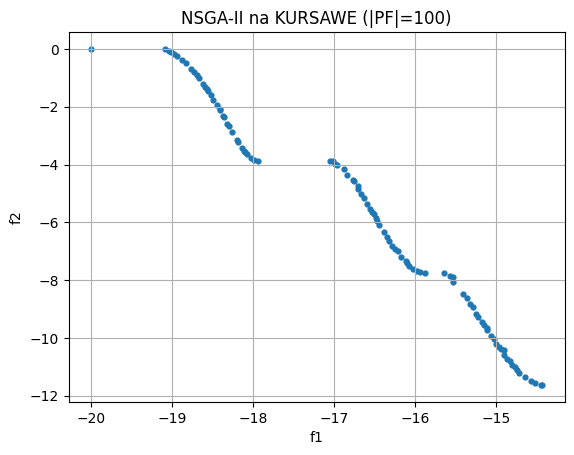

            0             1
0  -14.435479 -1.162729e+01
1  -20.000000  9.070557e-08
2  -19.081699 -1.834253e-05
3  -17.940986 -3.875762e+00
4  -17.047606 -3.875768e+00
..        ...           ...
95 -14.867703 -1.071759e+01
96 -17.014300 -3.884392e+00
97 -18.072602 -3.651224e+00
98 -16.216194 -7.001467e+00
99 -19.009313 -1.131534e-01

[100 rows x 2 columns]


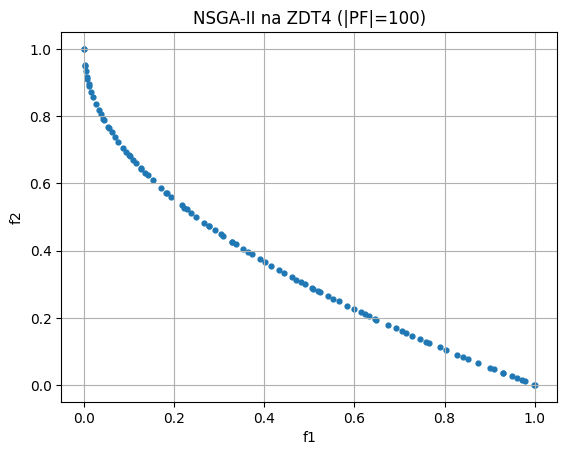

               0         1
0   1.869330e-14  1.000514
1   1.869330e-14  1.000514
2   9.999996e-01  0.000257
3   6.747927e-01  0.178845
4   4.156266e-01  0.355657
..           ...       ...
95  7.286052e-01  0.146711
96  1.831156e-01  0.572484
97  9.598199e-01  0.020558
98  1.278193e-01  0.642904
99  6.821222e-02  0.739272

[100 rows x 2 columns]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import plotly.express as px
import pandas as pd

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.problems import get_problem


def run_nsga2(problem_name: str, pop_size=100, n_eval=10000000, seed=10):
    problem = get_problem(problem_name)

    algorithm = NSGA2(
        pop_size=pop_size,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=20),
        mutation=PM(prob=1.0 / problem.n_var, eta=20),
        eliminate_duplicates=True
    )

    res = minimize(
        problem,
        algorithm,
        termination=("n_eval", n_eval),
        seed=seed,
        save_history=False,
        verbose=False
    )
    return problem, res


def plot_front(problem, res, title):
    F = res.F
    plt.figure()
    plt.scatter(F[:, 0], F[:, 1], s=12)
    plt.title(title)
    plt.xlabel("f1")
    plt.ylabel("f2")
    plt.grid(True)
    plt.show()

def plot(res):
    df = pd.DataFrame(res.F)
    print(df)
    fig = px.scatter(df, x=0, y=1)

    fig.update_layout(
        plot_bgcolor="black",
        paper_bgcolor="black",
        font_color="white",
        title_font_color="white",
        legend_title_font_color="white",
        xaxis_title="F1",
        yaxis_title="F2",
        width=800,
        height=600
    )

    # Białe osie
    fig.update_xaxes(color="white", gridcolor="gray",scaleanchor="y",
    scaleratio=2)
    fig.update_yaxes(color="white", gridcolor="gray")
    
    fig.show()


if __name__ == "__main__":
    # SCH, KUR, ZDT4
    for name in ["kursawe", "zdt4", "zdt6"]:
        problem, res = run_nsga2(name, pop_size=100, n_eval=250_000, seed=1)
        plot_front(problem, res, f"NSGA-II na {name.upper()} (|PF|={len(res.F)})")
        plot(res)


<div align="center">

## Zadanie 4

</div>